In [16]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch

import temperature_scaling as ts

from utils.calibration_plots import adaptive_make_calibration_plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def get_and_filter_preds(df, endpoint):
    preds = df[endpoint + '_pred']
    labels = df[endpoint + '_true']

    mask = labels.isin([0, 1])

    preds = preds[mask]
    labels = labels[mask]

    preds = torch.tensor(preds.values)
    labels = torch.tensor(labels.values)

    preds_logits = torch.log(preds / (1 - preds))

    return preds_logits, preds, labels

## One Model

In [30]:
import config as config
# exp_name = "TransRP_DenseNet121_m2 FIX"
# exp_dir = os.path.join("experiments", exp_name) # "experiments/TransRP_ResNet18_m2 FIX"
# model_name = "TransRP_DenseNet121_m2"

exp_name = "Best MedViT"
exp_dir = os.path.join("final_models_2", exp_name) # "experiments/TransRP_ResNet18_m2 FIX"
model_name = "MedViT_base"

prediction_scaling_methods = {
    "temperature scaling" : ts.TemperatureScaler() , 
    "platt scaling" : ts.PlattScaler(), 
    "isotonic regression": ts.IsotonicRegressionScaler(), 
    "beta calibration": ts.BetaCalibration()
    }

original_results = {}
method_results = {}

folders = os.listdir(exp_dir)


for scaling_method, model in prediction_scaling_methods.items():

    ens_preds_dict = {endpoint: None for endpoint in config.endpoint_list}
    scaled_ens_preds_dict = {endpoint: None for endpoint in config.endpoint_list}
    true_labels_dict = {endpoint: None for endpoint in config.endpoint_list}

    for folder in folders:
        #if "_2_" in folder:
        #    continue
        print(folder)
        #print(folder)
        #print(folder)
        df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
        df_preds = pd.read_csv(df_preds_dir, delimiter=';')
        df_val = df_preds[df_preds['Mode'] == 'val']
        df_test = df_preds[df_preds['Mode'] == 'test']

        for endpoint in config.endpoint_list:
            # first find the scaling by using the validation set
            val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

            
            model.fit(val_logits, val_labels)

            test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)

            test_logreg_preds = model.predict_proba(test_logits)
            #test_logreg_preds = torch.tensor(test_logreg_preds)
            #logreg_preds = torch.sigmoid(torch.tensor(logreg_logits))

            if ens_preds_dict[endpoint] is None:
                ens_preds_dict[endpoint] = test_preds/5
                scaled_ens_preds_dict[endpoint] = test_logreg_preds/5
                true_labels_dict[endpoint] = test_labels
            else:
                ens_preds_dict[endpoint] += test_preds/5
                scaled_ens_preds_dict[endpoint] += test_logreg_preds/5

   
    method_results[scaling_method] = scaled_ens_preds_dict


method_results["original"] = ens_preds_dict

20240628_073526_1_101_12_MedViT_base_params_52021913_auc_tr_0.739_val_0.699_test_0.701
20240628_073526_2_101_12_MedViT_base_params_52021913_auc_tr_0.72_val_0.745_test_0.684
20240628_073526_3_101_3_MedViT_base_params_52021913_auc_tr_0.662_val_0.713_test_0.697
20240628_073526_4_101_14_MedViT_base_params_52021913_auc_tr_0.736_val_0.681_test_0.7
20240628_073526_5_101_10_MedViT_base_params_52021913_auc_tr_0.733_val_0.697_test_0.69_avg_tr_0.718_val_0.707_test_0.695_ens_0.701
20240628_073526_1_101_12_MedViT_base_params_52021913_auc_tr_0.739_val_0.699_test_0.701
20240628_073526_2_101_12_MedViT_base_params_52021913_auc_tr_0.72_val_0.745_test_0.684
20240628_073526_3_101_3_MedViT_base_params_52021913_auc_tr_0.662_val_0.713_test_0.697
20240628_073526_4_101_14_MedViT_base_params_52021913_auc_tr_0.736_val_0.681_test_0.7
20240628_073526_5_101_10_MedViT_base_params_52021913_auc_tr_0.733_val_0.697_test_0.69_avg_tr_0.718_val_0.707_test_0.695_ens_0.701
20240628_073526_1_101_12_MedViT_base_params_52021913

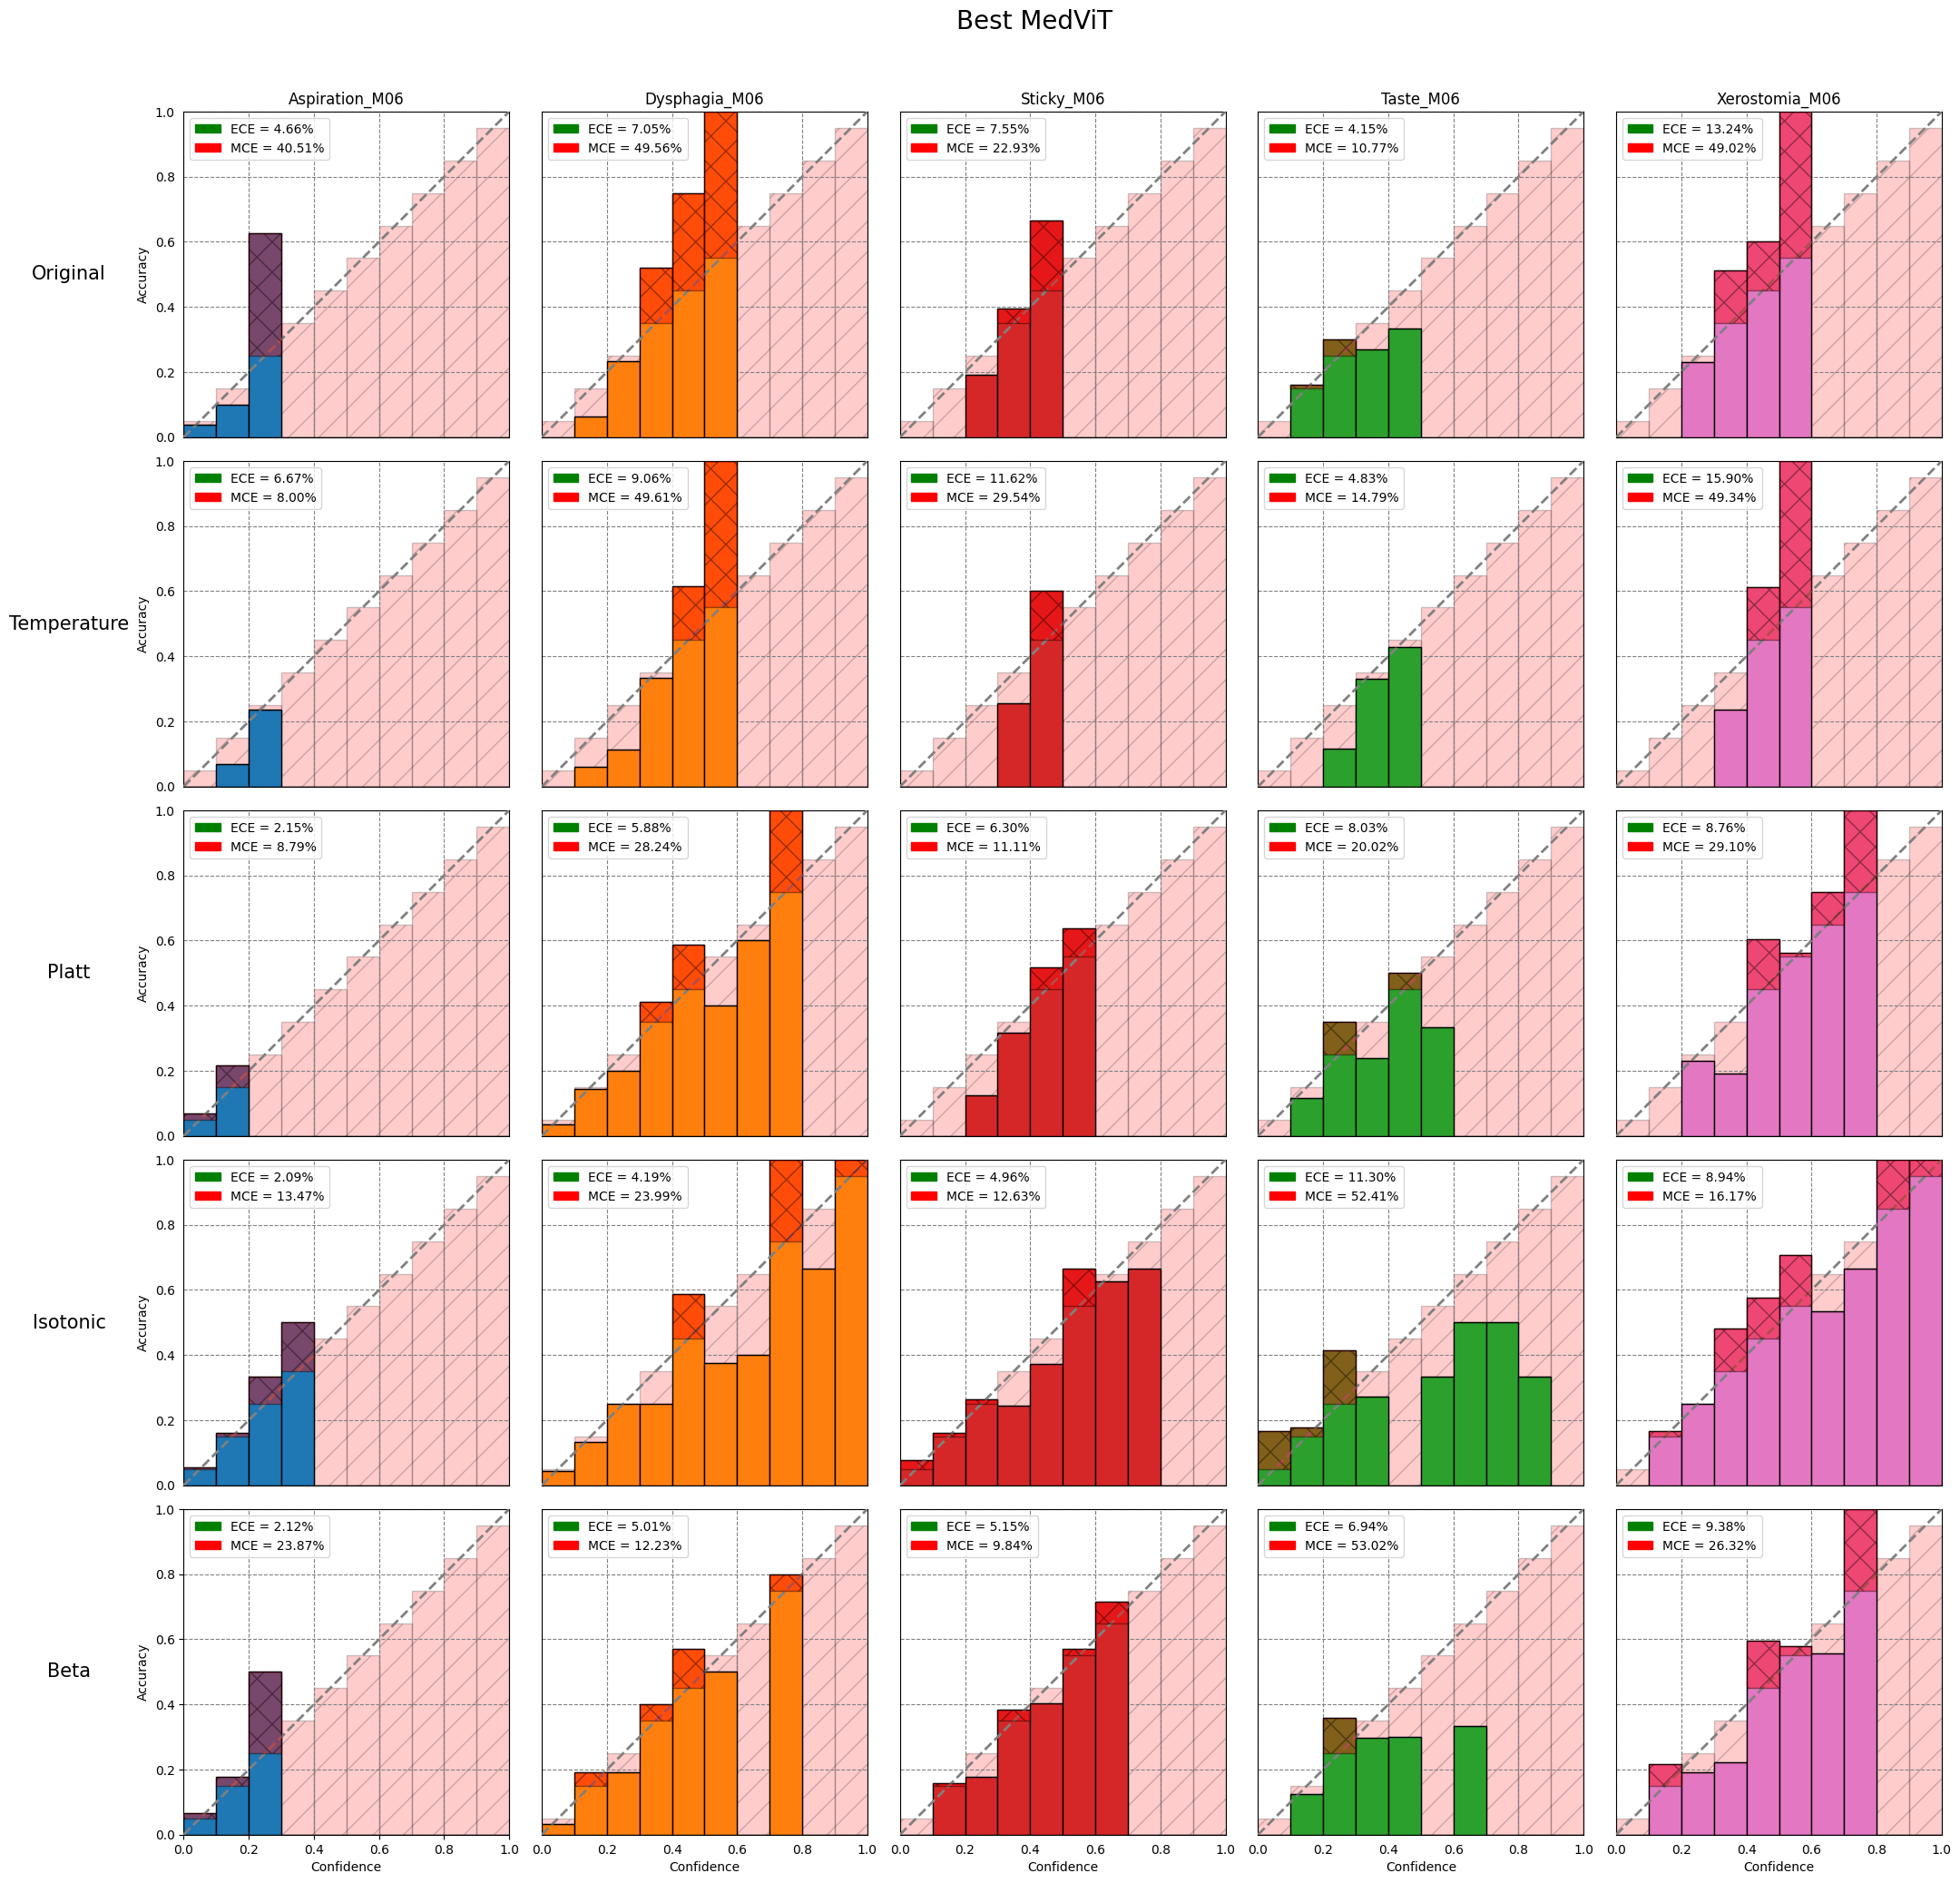

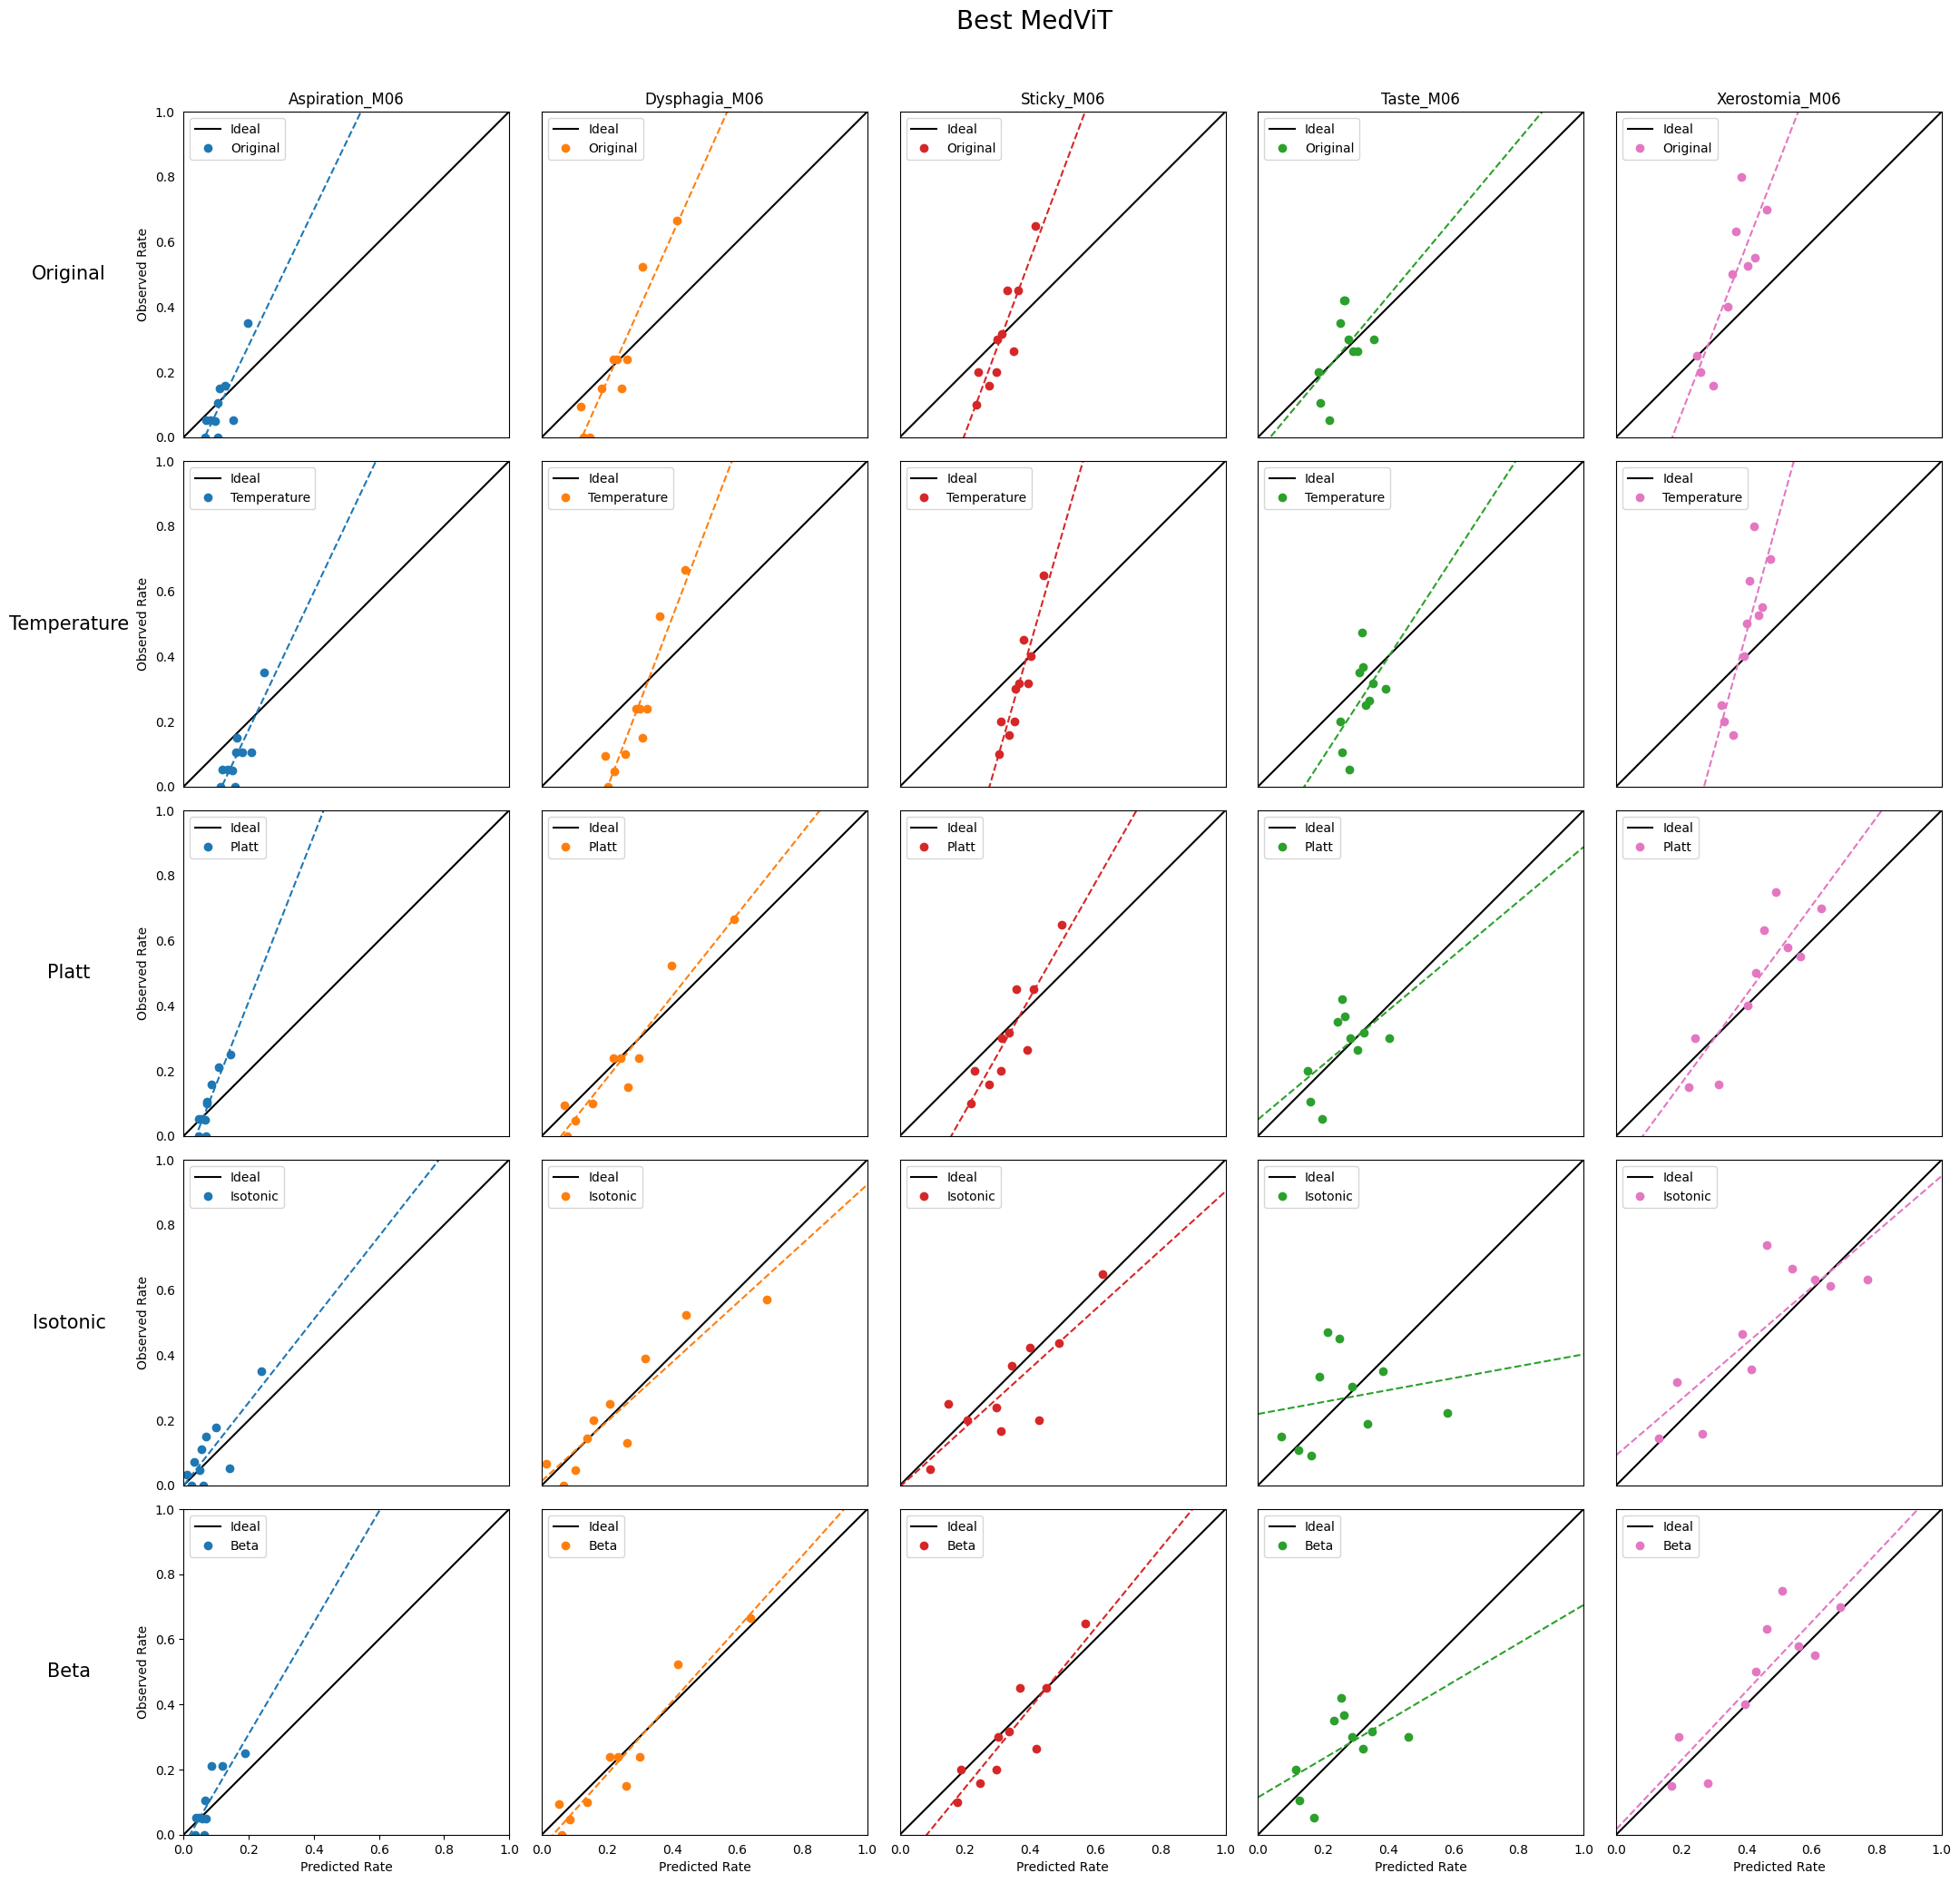

In [31]:
big_results_dict = [
    {
        "name": "Original",
        "preds": method_results["original"], 
        "labels": true_labels_dict
    }, {
        "name": "Temperature", 
        "preds": method_results["temperature scaling"], 
        "labels": true_labels_dict
    }, {
        "name": "Platt", 
        "preds": method_results["platt scaling"], 
        "labels": true_labels_dict
    },
    {"name": "Isotonic", "preds": method_results["isotonic regression"], "labels": true_labels_dict},
    {"name": "Beta", "preds": method_results["beta calibration"], "labels": true_labels_dict}
]


rel_plot_export_dir = os.path.join("Temperature Scaling", f"{exp_name}_reliability.png")
cal_plot_export_dir = os.path.join("Temperature Scaling", f"{exp_name}_calibration.png")

%matplotlib inline
fig = adaptive_make_calibration_plots(config, row_dicts=big_results_dict, column_names=config.endpoint_list, title=exp_name, 
                                      mode='reliability', filedir=rel_plot_export_dir, return_fig=True)
plt.show()
plt.close()
fig = adaptive_make_calibration_plots(config, row_dicts=big_results_dict, column_names=config.endpoint_list, title=exp_name, 
                                      mode='calibration', filedir=cal_plot_export_dir, return_fig=True)
plt.show()
plt.close()

In [20]:
from utils.metrics import compute_AUCs_for_multiple_endpoints
from sklearn.metrics import roc_auc_score

#compute_AUCs_for_multiple_endpoints(config, method_results["original"], true_labels_dict)

for endpoint in config.endpoint_list:
    print(endpoint)
    for key in method_results.keys():
        
    
        auc_value = roc_auc_score(true_labels_dict[endpoint].clone().detach().cpu().numpy(), method_results[key][endpoint].clone().detach().cpu().numpy())
        #auc_value_new = roc_auc_score(true_labels_dict[endpoint].clone().detach().cpu().numpy(), method_results["temperature scaling"][endpoint].clone().detach().cpu().numpy())
        print(f"  {auc_value:.4f}",  key )

Aspiration_M06
  0.7456 temperature scaling
  0.7365 platt scaling
  0.7304 isotonic regression
  0.7386 beta calibration
  0.7456 original
Dysphagia_M06
  0.8313 temperature scaling
  0.8319 platt scaling
  0.8253 isotonic regression
  0.8316 beta calibration
  0.8318 original
Sticky_M06
  0.6631 temperature scaling
  0.6618 platt scaling
  0.6591 isotonic regression
  0.6610 beta calibration
  0.6625 original
Taste_M06
  0.6639 temperature scaling
  0.6625 platt scaling
  0.6629 isotonic regression
  0.6620 beta calibration
  0.6629 original
Xerostomia_M06
  0.7684 temperature scaling
  0.7685 platt scaling
  0.7640 isotonic regression
  0.7685 beta calibration
  0.7686 original


## Many Models

In [2]:
# loop through the different model experiment folders
# rescale the predictions
# compare to the original predictions (can just find average of the unscaled preds for this, don't have to find the ensemble preds file)



